<a href="https://colab.research.google.com/github/Pradeep333Singh/Pw_Assignments_DataScience/blob/main/Anamoly_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 1: What is Anomaly Detection?
Explain its types (point, contextual, and collective anomalies) with examples.**

Answer:
Anomaly detection is a technique used in data mining and machine learning to identify unusual patterns, outliers, or events that deviate significantly from the expected behavior in a dataset.

*Here are its primary types*:

Point Anomalies: A single instance of data is considered anomalous if it falls far outside the normal range of the rest of the dataset.

*Example*: A sudden 100000 rupees credit card transaction on an account that typically only sees 5000 purchases.

Contextual Anomalies: An instance is considered anomalous only within a specific context (often time or location).

*Example*: A temperature reading of 30°C in New York is normal in July, but it would be a contextual anomaly if recorded in December.

Collective Anomalies: A collection of related data instances is anomalous with respect to the entire dataset, even if the individual points themselves might not be anomalies in isolation.

*Example*: A user logging into their account isn't anomalous, but 50 consecutive failed login attempts within two minutes is a collective anomaly indicating a potential brute-force cyberattack.

**Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.**

*Isolation Forest:*
* Tree-based ensemble method. It isolates anomalies by randomly partitioning data; anomalies require fewer partitions (shorter path lengths) to be isolated.
* Excellent for high-dimensional datasets. Used in fraud detection and network security. Fast and scalable for large datasets.

*DBSCAN:*
* Density-based clustering. Groups points closely packed together and marks points in low-density regions as outliers.
* Best for spatial data and discovering clusters of arbitrary shapes. Useful when anomalies are points scattered between distinct, dense clusters.

*Local Outlier Factor:*
* Density-based algorithm. Compares the local density of a data point to the local densities of its neighbors to find points with substantially lower density.
* Ideal for datasets where anomalies might be localized and varying densities exist across the dataset. Useful in sensor network monitoring.

**Question 3: What are the key components of a Time Series?
Explain each with one example.**

Answer:

*Trend:* The long-term underlying direction (increase, decrease, or stable) in the data over a long period.

Example: The steady increase in average global temperatures over the last century.

*Seasonality:* Regular, predictable, and repeating patterns or fluctuations that occur within a specific timeframe (like a year, month, or week).

Example: Retail sales spiking every year during the December holiday season.

*Cyclic Variations:* Fluctuations that occur over unpredictable durations (usually longer than a year), often tied to macroeconomic factors.

Example: Economic expansions and recessions (business cycles) that impact housing prices.

*Irregular/Residual (Noise):* Random, unpredictable variations that cannot be attributed to trend, seasonal, or cyclic components.

Example: A sudden drop in airline ticket sales on a specific day due to unexpected severe weather or a strike.

**Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?**

Answer:

Stationary refers to a time series whose statistical properties—such as mean, variance, and autocorrelation—are constant over time. Time series models (like ARIMA) often assume the data is stationary because predictable patterns are easier to model when the underlying distribution doesn't change.

How to Test for Stationarity:

*Visual Inspection*: Plotting the data to look for trends or changing variance.

*Statistical Tests:* The Augmented Dickey-Fuller (ADF) test is the most common. A p-value less than 0.05 generally indicates the series is stationary. The KPSS test is another alternative.

How to Transform Non-Stationary to Stationary:

*Differencing:* Subtracting the previous observation from the current observation.Log Transformation: Applying a natural logarithm to stabilize the variance over time.

*Seasonal Differencing:* Subtracting the value from the previous season (e.g., subtracting last January's value from this January's value).

**Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.**


Answer:

*AR (Autoregressive):* Structure uses the dependent relationship between an observation and some number of lagged observations (past values). Application: Predicting future stock prices based purely on its recent past prices.

*MA (Moving Average):* Structure uses the dependency between an observation and a residual error from a moving average model applied to lagged observations. Application: Smoothing out short-term fluctuations to highlight longer-term trends or cycles.

*ARIMA (Autoregressive Integrated Moving Average):* Structure combines AR, MA, and an "Integrated" (I) component representing the differencing of raw observations to make the time series stationary. Application: Forecasting standard non-stationary data (like monthly sales) without strong seasonal patterns.

*SARIMA (Seasonal ARIMA):* Structure extends ARIMA by explicitly adding terms to model seasonality (Seasonal AR, Seasonal MA, Seasonal Differencing). Application: Forecasting data with strong recurring patterns, like monthly airline passenger counts or quarterly earnings.

*SARIMAX (Seasonal ARIMA with eXogenous variables):* Structure extends SARIMA by adding exogenous variables (external factors) that might influence the dependent variable. Application: Forecasting ice cream sales using historical sales data plus external daily weather/temperature data.

**Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components**

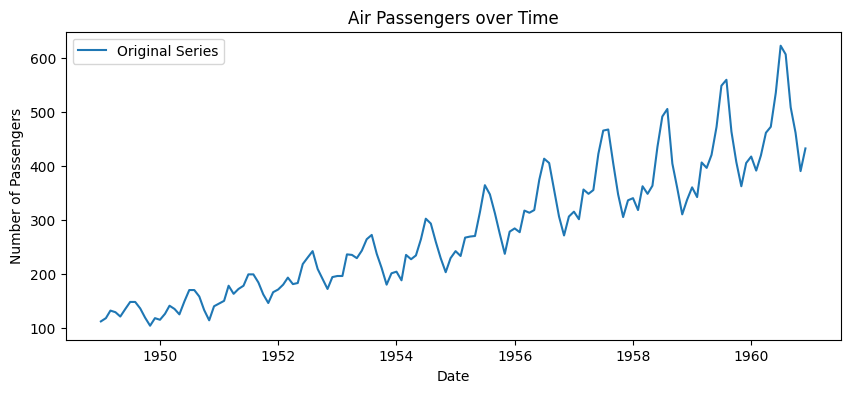

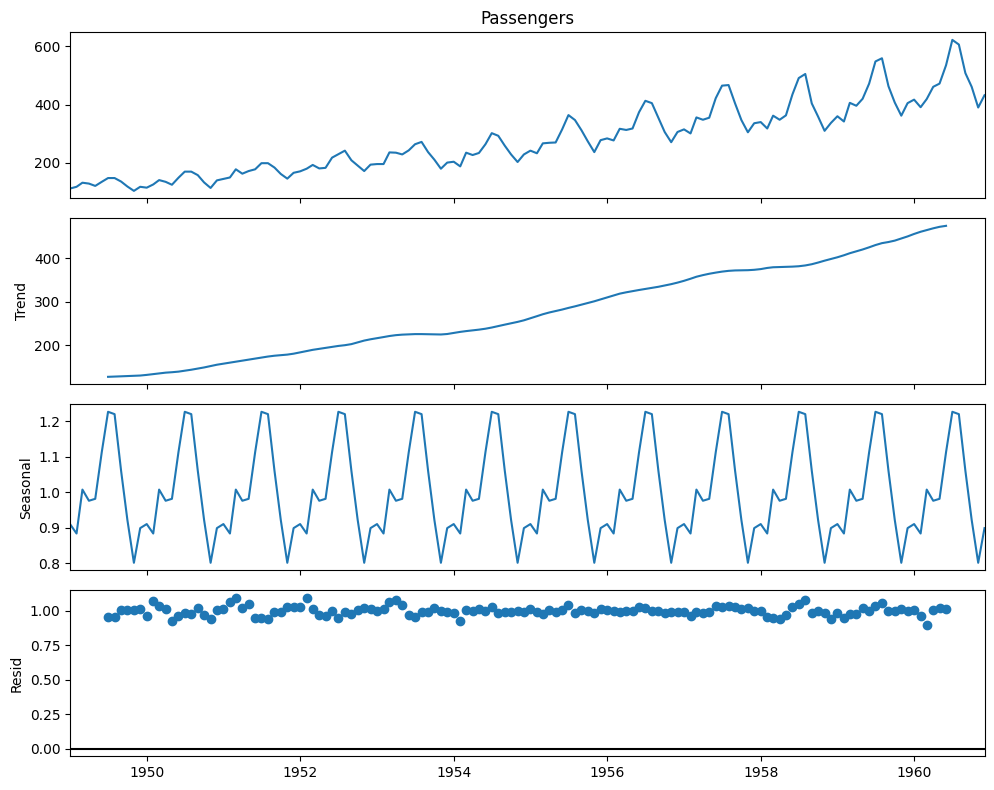

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the AirPassengers dataset (using a common public URL for ease of use in Colab)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Plot original series
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Passengers'], label='Original Series')
plt.title('Air Passengers over Time')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

# Decompose into trend, seasonality, and residual components
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

# Plot the decomposition
plt.rcParams.update({'figure.figsize': (10, 8)})
result.plot()
plt.show()

**Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.**

**Note** : The dataset is more than 500 mb

Loading dataset...
Sampling data...
Training Isolation Forest...
Generating plot...


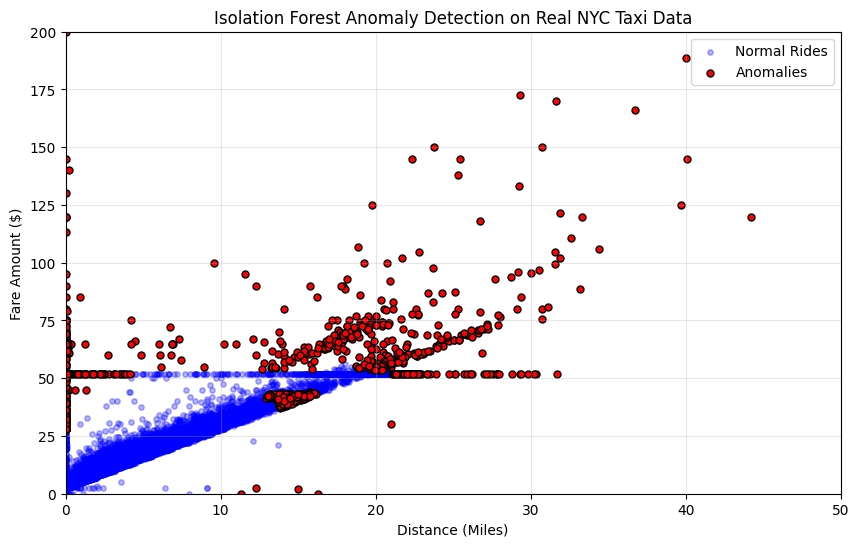

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Load the real dataset
# Replace 'nyc_taxi_data.csv' with the actual name of your uploaded 500MB file

file_path = 'NYC_taxi_fare_data.csv'

# We specify the columns we need to save memory while loading a 500MB file
# Assuming your dataset has 'trip_distance' and 'fare_amount' columns
# (standard for NYC TLC datasets)
columns_to_load = ['trip_distance', 'fare_amount']

print("Loading dataset...")
df = pd.read_csv(file_path, usecols=columns_to_load)

# 2. Data Cleaning & Sampling
# Drop any rows with missing values in our target columns
df = df.dropna()

# Drop completely illogical values (e.g., negative fares or negative distances)
# to help the model focus on true anomalies rather than basic data errors
df = df[(df['fare_amount'] >= 0) & (df['trip_distance'] >= 0)]

# Sample 50,000 rows for efficient processing and visualization
print("Sampling data...")
df_sample = df.sample(n=50000, random_state=42)

# Define the features for anomaly detection
X = df_sample[['trip_distance', 'fare_amount']]

# 3. Apply Isolation Forest
print("Training Isolation Forest...")
# contamination is the expected proportion of outliers (set to 2%)
iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)

# Fit the model and predict (-1 indicates anomaly, 1 indicates normal)
df_sample['anomaly'] = iso_forest.fit_predict(X)

# Isolate normal points and anomalies based on predictions
normal = df_sample[df_sample['anomaly'] == 1]
anomalies = df_sample[df_sample['anomaly'] == -1]

# 4. Visualize on a 2D scatter plot
print("Generating plot...")
plt.figure(figsize=(10, 6))

# Plot normal data first
plt.scatter(normal['trip_distance'], normal['fare_amount'],
            color='blue', label='Normal Rides', alpha=0.3, s=15)

# Plot anomalies on top in red
plt.scatter(anomalies['trip_distance'], anomalies['fare_amount'],
            color='red', label='Anomalies', edgecolors='black', s=25)

# Adding limits to zoom in on the most relevant data
# (NYC taxi data often has crazy extreme outliers like a $500,000 fare typo)
# You can remove or adjust these xlim/ylim bounds based on your specific data
plt.xlim(0, 50)
plt.ylim(0, 200)

plt.title('Isolation Forest Anomaly Detection on Real NYC Taxi Data')
plt.xlabel('Distance (Miles)')
plt.ylabel('Fare Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Question 8: Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.**

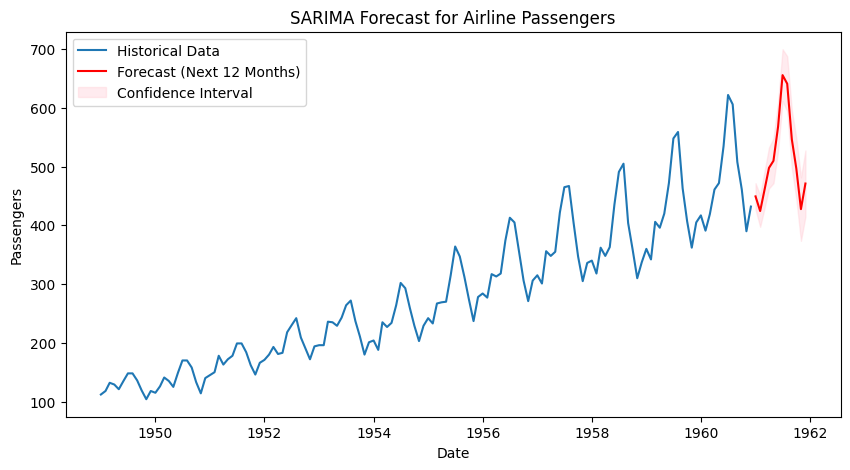

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Train SARIMA Model (Order and Seasonal Order chosen for standard AirPassenger patterns)
model = SARIMAX(df['Passengers'],
                order=(1, 1, 1),              # (p, d, q)
                seasonal_order=(1, 1, 1, 12)) # (P, D, Q, s)
results = model.fit(disp=False)

# Forecast the next 12 months
forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Visualize the results
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'], label='Historical Data')
plt.plot(forecast_index, forecast_mean, color='red', label='Forecast (Next 12 Months)')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')
plt.title('SARIMA Forecast for Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

**Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.**

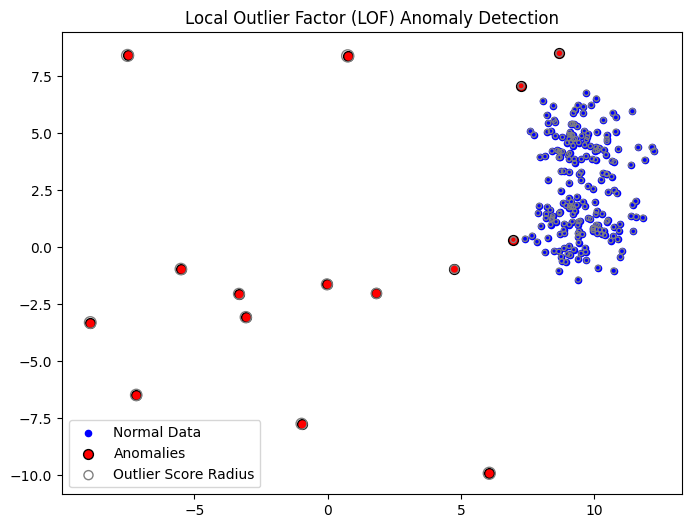

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

# Generate a numerical dataset with clusters and outliers
X, _ = make_blobs(n_samples=200, centers=2, cluster_std=1.0, random_state=4)
# Add some intentional outliers
outliers = np.random.uniform(low=-10, high=10, size=(15, 2))
X_data = np.vstack([X, outliers])

# Apply Local Outlier Factor
# n_neighbors specifies the number of neighbors to consider for density calculation
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.07)
predictions = lof.fit_predict(X_data)
# LOF outputs -1 for outliers and 1 for inliers

# Isolate normal points and outliers based on predictions
normal_points = X_data[predictions == 1]
anomaly_points = X_data[predictions == -1]

# Calculate anomaly scores for circle sizing (negative outlier factor)
scores = -lof.negative_outlier_factor_

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(normal_points[:, 0], normal_points[:, 1], color='blue', label='Normal Data', s=20)
plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1], color='red', label='Anomalies', s=50, edgecolors='black')

# Optional: Draw circles around points proportional to their anomaly score
plt.scatter(X_data[:, 0], X_data[:, 1], s=10 * scores, edgecolors='gray', facecolors='none', label='Outlier Score Radius')

plt.title('Local Outlier Factor (LOF) Anomaly Detection')
plt.legend()
plt.show()

**Question 10: You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage. Explain your real-time data science workflow:**



**How would you detect anomalies in this streaming data (Isolation Forest / LOF / DBSCAN)?**

For streaming data with multiple features (weather, region, usage), Isolation Forest is highly suitable due to its speed and ability to handle multidimensional data efficiently. It can be periodically retrained in micro-batches to adapt to new baseline consumption patterns. DBSCAN struggles with varying densities (which grid data has), and LOF can be computationally expensive for real-time streaming at a 15-minute granularity over millions of nodes.


**Which time series model would you use for short-term forecasting (ARIMA / SARIMA / SARIMAX)?**

I would use SARIMAX. Power consumption exhibits strong multi-seasonal patterns (daily and weekly cycles), necessitating the "Seasonal" component. More importantly, grid demand is heavily dependent on weather conditions (temperature, humidity), which act as vital "eXogenous" (X) variables.


**How would you validate and monitor the performance over time?**

I would validate forecasting models using time-series cross-validation (rolling forecasting origin) calculating metrics like MAE and RMSE. To monitor in real-time, I'd track data drift and prediction residuals; if the forecast error exceeds a threshold standard deviation, it triggers an alert indicating the model may need retraining. For anomalies, precision and recall would be validated against logged historical incidents.


**How would this solution help business decisions or operations?**
Accurate short-term forecasting allows the grid to efficiently route power, balance generation loads, and prevent brownouts. Anomaly detection enables preventative maintenance by flagging faulty transformers or instances of power theft in real-time, significantly reducing downtime and financial loss.

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

# Simulating a streaming batch of 15-minute grid data (Energy Usage & Temperature)
# Imagine this function is triggered every 15 minutes
def real_time_grid_monitor(new_data_batch, historical_data):
    # 1. Anomaly Detection (Isolation Forest)
    # Train/Update model on recent historical data
    iso_forest = IsolationForest(contamination=0.01, random_state=42)
    features = ['energy_usage', 'temperature']
    iso_forest.fit(historical_data[features])

    # Predict on the new incoming batch
    new_data_batch['anomaly_status'] = iso_forest.predict(new_data_batch[features])

    anomalies = new_data_batch[new_data_batch['anomaly_status'] == -1]
    if not anomalies.empty:
        print(f"ALERT: Detected {len(anomalies)} anomalies in the grid!")
        print(anomalies[['timestamp', 'energy_usage', 'temperature']])
    else:
        print("Grid status normal. No anomalies detected in this batch.")

    return new_data_batch

# --- Mock Output Generation ---
# Historical training data
hist_data = pd.DataFrame({
    'timestamp': pd.date_range(start='2026-02-01', periods=1000, freq='15min'),
    'energy_usage': np.random.normal(500, 50, 1000),
    'temperature': np.random.normal(70, 10, 1000)
})

# New data batch arriving (one normal reading, one spike)
new_batch = pd.DataFrame({
    'timestamp': [pd.Timestamp('2026-02-11 10:00'), pd.Timestamp('2026-02-11 10:15')],
    'energy_usage': [510, 1200], # 1200 is a massive spike
    'temperature': [72, 73]
})

processed_batch = real_time_grid_monitor(new_batch, hist_data)

Grid status normal. No anomalies detected in this batch.
